# EEGNET


This model has been built based on the model by Vernon J Lawhern et al 2018 J. Neural Eng. 15 056013.

Link to their original code:
https://github.com/vlawhern/arl-eegmodels/blob/master/EEGModels.py

In [22]:
# imports

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.gridspec as gridspec
import os
import glob
from pathlib import Path
from collections import defaultdict
from scipy.signal import decimate
import torch
from torch.utils.data import Dataset, DataLoader
import keras
from keras import layers, models, regularizers
from keras.constraints import max_norm


In [23]:
# set up
DATA_ROOT = Path('../data')
INTRA_TRAIN = DATA_ROOT / 'Intra' / 'train'
INTRA_TEST  = DATA_ROOT / 'Intra' / 'test'
CROSS_TRAIN = DATA_ROOT / 'Cross' / 'train'
CROSS_TEST1 = DATA_ROOT / 'Cross' / 'test1'
CROSS_TEST2 = DATA_ROOT / 'Cross' / 'test2'
CROSS_TEST3 = DATA_ROOT / 'Cross' / 'test3'

TASK_LABELS = {
    'rest': 0,
    'task_motor': 1,
    'task_story_math': 2,
    'task_working_memory': 3,
}
LABEL_NAMES = {v: k for k, v in TASK_LABELS.items()}
SAMPLE_RATE = 2034  # Hz
DECIMATION_FACTOR = 8
WINDOW_SEC = 2.0
N_SENSORS = 248
N_CLASSES = len(TASK_LABELS)
N_SAMPLES_PER_WINDOW = int(SAMPLE_RATE * WINDOW_SEC / DECIMATION_FACTOR) # 2034 * 2 / 8 (about 509 samples per window )


## 1. Dataset Pre-processing

In [24]:
# normalize each sample to zero mean and unit variance

def z_score_normalize(matrix):
    """Time-wise Z-score: each sensor normalised over its own time axis.

    NOTE: MEG values are ~1e-11 T with a per-sensor std of ~1e-12. A fixed additive
    epsilon (e.g. 1e-8) would dominate the denominator and crush the output toward 0,
    so we only guard genuinely flat sensors instead, preserving unit variance.
    """
    mu  = matrix.mean(axis=1, keepdims=True)
    std = matrix.std(axis=1, keepdims=True)
    std = np.where(std < 1e-20, 1.0, std)
    return (matrix - mu) / std



def compute_subject_stats(filepaths):
    """ returns {subject_id: (mean, std)} for all subjects in the filepaths, where mean and std are computed across all data from that subject (all files)"""

    by_subject = {}
    for filepath in filepaths:
        subject = get_subject(filepath)
        raw = load_h5(filepath) # shape (248, 35624)
        by_subject.setdefault(subject, []).append(raw)


    subject_stats = {}
    for subject, data_list in by_subject.items():
        all_data = np.concatenate(data_list, axis=1) # concatenate along time axis, shape (248, total_time_samples)
        mu = all_data.mean(axis=1, keepdims=True) # mean per sensor, shape (248, 1)
        std = all_data.std(axis=1, keepdims=True) # std per sensor, shape (248, 1)
        std = np.where(std < 1e-20, 1.0, std) # guard against flat sensors
        subject_stats[subject] = (mu.astype(np.float32), std.astype(np.float32))
    return subject_stats


# downsampling
# downsample by taking every nth sample, where n is the factor (with n=8 we downsample from 2034 Hz to ~254 Hz)
def downsample(x, factor = 8):
    return decimate(x, factor, axis=1, zero_phase=True).astype(np.float32)


def make_windows(x, samples_per_window):
    """Split the signal into non-overlapping windows of fixed length.
    x: shape (n_sensors, n_samples)
    returns: shape (n_windows, n_sensors, window_size)"""

    # calculate how many full windows we can make
    n_samples = x.shape[1] # total number of samples in the signal 
    n_windows = n_samples // samples_per_window # = n_samples // (SAMPLE_RATE * WINDOW_SEC / DECIMATION_FACTOR)  -integer for only full windows

    # trim the signal to have only full windows
    x = x[:, :n_windows * samples_per_window] # keep only the part of the signal that fits into full windows

    # reshape to (n_windows, n_sensors, window_size)
    return x.reshape(x.shape[0], n_windows, samples_per_window).transpose(1, 0, 2) # first reshape to (n_sensors, n_windows, window_size) then transpose to (n_windows, n_sensors, window_size)



# helper functions

def get_dataset_name(filepath):


    # The files have the following format: 
    # “taskType_subjectIdentifier_number.h5” 
    # where taskType can be rest, task motor, task story math, and task working memory
    # e.g. rest_105923_1.h5, mean task type is rest, subject identifier is 105923, and number is 1).

    name = Path(filepath).stem         
    parts = name.split('_')[:-1]        # drop trailing chunk number
    return '_'.join(parts)

def load_h5(filepath):
    filepath = str(filepath)
    with h5py.File(filepath, 'r') as f:
        ds_name = get_dataset_name(filepath)
        X = f.get(ds_name)[()] # shape (248, 35624)
    return X

def get_label(filepath):
    stem = Path(filepath).stem
    parts = stem.split('_')[:-2]  # only keep the task type, drop subject identifier and chunk number
    task = '_'.join(parts)
    if task not in TASK_LABELS:
        raise ValueError(f'Unknown task in filename: {filepath}')
    return TASK_LABELS[task]

def get_subject(filepath):
    """Extract the subject identifier from the filename"""
    name = Path(filepath).stem         
    parts = name.split('_')[:-1]        # drop trailing chunk number
    for p in parts:
        if p.isdigit() and len(p) == 6:
            return p
    raise ValueError(f'No subject identifier found in filename: {filepath}')

def list_files(folder):
    return sorted(Path(folder).glob('*.h5'))








def build_dataset(filepaths, subject_stats=None):
    all_windows, all_labels = [], []
    for filepath in filepaths:
        # load one file and preprocess it to get windows and label
        raw = load_h5(filepath)                           # shape (248, 35624)
        if subject_stats:    # for cross-subject classification we want to have subject-based normalization
    
            subject = get_subject(filepath)
            mu, std = subject_stats[subject]
            normed = ((raw - mu) / std).astype(np.float32)    
        
        else:
            normed = z_score_normalize(raw)               # shape (248, 35624)
        decimated = downsample(normed, DECIMATION_FACTOR) # shape (248, 4453)
        window = make_windows(decimated, N_SAMPLES_PER_WINDOW) # shape (n_windows, 248, 509)
        label = get_label(filepath) # scalar label for the whole file
        
        
        all_windows.append(window)
        all_labels.append(np.full(len(window), label, dtype=np.int64)) # create an array of shape (n_windows,) filled with the label label (every window in the file gets the (same) file's label)


    # concatenate all windows and labels from all files into one big dataset
    X = np.concatenate(all_windows, axis=0) # shape (total_windows, 248, 509)
    y = np.concatenate(all_labels, axis=0)  # shape (total_windows,)+

    # Keras Conv2D expects input shape (batch_size, height, width, channels)
    # for our data:
    # height = number of sensors (248)
    # width = number of time points (time steps) in the window (509)
    # channels = 1 (the image has only one channel, like grayscale)
    # we look at each sample (2-second window)  as a grayscale image with 248 pixels in height (one per sensor) and 509 pixels in width (one per time point), and 1 channel (because it's like a grayscale image)
    X = X[..., np.newaxis] # add a new axis at the end to represent the channel dimension, shape becomes (total_windows, 248, 509, 1)


    counts = np.bincount(y, minlength=N_CLASSES)
    print (f'Loaded {len(X)} windows from {len(filepaths)} files. Class distribution: {counts}')
    
    return X, y


## EEGnet Model

In [25]:
# EEGNet architecture based on the original paper and adapted for our input shape
# Input shape: (batch_size, 1, n_sensors, n_samples_per_window) = (batch_size, 1, 248, 509)
   

def EEGNet(n_channels=N_SENSORS, # number of sensors (248)
           n_classes=N_CLASSES, # number of classes (4)
           n_samples=N_SAMPLES_PER_WINDOW, # number of time samples (509)
           F1=8, # number of temporal filters in the first layer
           F2=None, # number of temporal filters in the second layer (if None, will be set to F1 * D)
           D=2, # number of spatial filters to learn within each temporal convolution
           dropout_rate=0.5,
           norm_rate=0.25
           ):
   """
   inputs:
   - n_channels: number of sensors (248)
   - n_classes: number of classes (4)
   - n_samples: number of time samples (509)
   - F1, F2: number of temporal filters in the first layer and second layer (F2 = F1 * D)
   - D: number of spatial filters to learn within each temporal convolution
   - dropout_rate: rate for dropout regularization

   """
   input = layers.Input(shape= (n_channels, n_samples, 1)) # input shape (248, 509, 1)

   #EFFECTIVE_SAMPLE_RATE = SAMPLE_RATE // DECIMATION_FACTOR # effective sample rate after downsampling (2034 / 8 = ~254 Hz)
   # kernel_size_1 = (1, EFFECTIVE_SAMPLE_RATE //2) # temporal convolution kernel size (1, 127)
   # kernel_size_2 = (n_channels, 1) # spatial convolution kernel size (248, 1)
   # kernel_size_3 =  (1, EFFECTIVE_SAMPLE_RATE //8) # second temporal convolution kernel size (1, 32)


   # pool_size_1 = (1, 8)    # pooling size for first block
   # pool_size_2 = (1,16)    # pooling size for second block


   # since our sampling rate is about double that of the original paper, we double the pooling sizes

   kernel_size_1 = (1, 64)
   kernel_size_2 = (n_channels, 1)
   kernel_size_3 =  (1, 16)

   pool_size_1 = (1, 4)
   pool_size_2 = (1,8)    
   ############################################################
   
   # First block: temporal convolution + spatial convolution

   ############################################################


   # temporal convolution: kern spans time axis only, not sensors (spatial axis)
   # learns temporal features (like frequency filters) 

   x = layers.Conv2D(
            filters=F1, 
            kernel_size=kernel_size_1, # (1, samples_per_window//2) 
            padding='same', 
            use_bias=False,
            # kernel_regularizer=regularizers.l2(1e-4), # L2 regularization to prevent overfitting
   )  (input) # apply temporal convolution, output shape (248, 509, F1)
   x = layers.BatchNormalization(momentum=0.9)(x) # batch normalization to stabilize training, output shape (248, 509, F1)


   # depthwise spatial convolution: kernel spans all sensors but only one time point, learns sensor weighting

   x = layers.DepthwiseConv2D(
            kernel_size=kernel_size_2, # (n_channels, 1)
            depth_multiplier=D, 
            use_bias=False,
            depthwise_constraint=max_norm(1.0), # regularizer: constrain the weights to prevent them from growing too large
   ) (x) # output shape (1, 509, F1 * D) because we convolve across all sensors and learn D filters per temporal filter

   x = layers.BatchNormalization(momentum=0.9)(x) 
   x = layers.Activation('elu')(x) # non-linearity
   x = layers.AveragePooling2D(pool_size=pool_size_1)(x) # downsample in time dimension, output shape (1, 128, F1 * D)
   x = layers.SpatialDropout2D(dropout_rate)(x) # spatial dropout for regularization
   
   
   ############################################################
      
      # Second block: separable convolution
      
   ############################################################
   
   if F2 is None:
      F2 = F1 * D 

   # depthwise convolution: learn temporal features separately for each spatial filter
   x = layers.SeparableConv2D(
            filters=F2, 
            kernel_size=kernel_size_3, # (1, samples_per_window//8)
            padding='same', 
            use_bias=False,
   ) (x) # output shape (1, 128, F2) 

   x = layers.BatchNormalization(momentum=0.9)(x)
   x = layers.Activation('elu')(x)
   x = layers.AveragePooling2D(pool_size=pool_size_2)(x) # downsample in time dimension, output shape (1, 16, F2)
   x = layers.SpatialDropout2D(dropout_rate)(x) # spatial dropout for regularization


   ############################################################

      # Classification

   #############################################################


   flatten = layers.Flatten()(x) # flatten to (F2 * 16,)

   output = layers.Dense(n_classes, 
                        kernel_constraint=max_norm(norm_rate)) (flatten) # final classification layer, output shape (n_classes,)
   
   # Note: instead of using a softmax here like on the original paper, we will use the logits output by this layer directly and apply the softmax in the loss function (from_logits=True) for better numerical stability. So we don't add an activation here.

   model = models.Model(inputs=input, outputs=output)
   return model

## Train and Evaluate

In [26]:

def run_eegnet(train_files, validation_files, test_files, epochs = 30, batch_size = 32, lr = 5e-4, save_path = None, use_subject_norm=False):
   
   # compute subject stats for normalization if needed (for cross)
   if use_subject_norm:
      print("Computing per-subject statistics for normalization...")
      
      # train and validation have the same subjects (but different files), so we can compute the stats on the combined set of train and validation files
      train_val_stats = compute_subject_stats(list(train_files) + list(validation_files))

      # for test files we compute stats separately for each test set, since they have different subjects
      test_stats = {name: compute_subject_stats(files) for name, files in test_files.items()}
   else:
      train_val_stats = None
      test_stats = {name: None for name in test_files}
   
   
   # build datasets
   print('Building training dataset')
   X_train, y_train = build_dataset(train_files, subject_stats=train_val_stats)

   print('Building validation dataset')
   validation_data = build_dataset(validation_files, subject_stats=train_val_stats)

   print('Building test dataset')
   test_data = {name : build_dataset(files, subject_stats=test_stats[name]) for name, files in test_files.items()}


   # build model
   model = EEGNet()
   model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=lr),
      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), # use from_logits=True because our model outputs raw logits without softmax
      metrics=['accuracy']
   )

   # train model

   callbacks=[
         keras.callbacks.EarlyStopping(
            patience = 10, restore_best_weights=True, monitor='val_loss'
         ), # early stopping to prevent overfitting. using val_loss because it is a more stable metric than val_accuracy which can be noisy especially with small validation sets. 
      
         keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
         ), # reduce learning rate if validation loss plateaus to help model converge to a better minimum
      
      
      
      ]
      
   if save_path is not None:
      callbacks.append(
         keras.callbacks.ModelCheckpoint(
            save_path, save_best_only=True, 
            monitor='val_loss', verbose=1
         )
      ) # save the best model during training



   history = model.fit(
      X_train, y_train, 
      validation_data=validation_data, 
      epochs=epochs, 
      batch_size=batch_size,
      verbose=2,
      callbacks=callbacks,
      
   )

   loss, acc = model.evaluate(X_train, y_train, verbose=0)
   print(f'Training set: loss={loss:.3f}, accuracy={acc:.3f}')


   # test the model

   print('test results:')
   results = {}
   predictions = {}
   for name, (X_test, y_test) in test_data.items():
      loss, acc = model.evaluate(X_test, y_test, verbose=0)
      pred = model.predict(X_test).argmax(axis=1)
      print(f'{name}: loss={loss:.3f}, accuracy={acc:.3f}')
      results[name] = (loss, acc)
      predictions[name] = {
         'y_true': y_test,
         'y_pred': pred
      }

   return model, history, results, predictions

### Visualizations

In [27]:
# training history

def plot_history(history, title='Training History', save_path=None):
    plt.figure(figsize=(12, 5))
    plt.suptitle(title)

    # plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss')

    # plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    if save_path is not None:
        plt.savefig(save_path)
    
    plt.show()

# confusion matrix
def plot_confusion_matrix(predictions, title='Confusion Matrix', save_path=None):
    n_sets = len(predictions)
    plt.figure(figsize=(5 * n_sets, 4))

    class_names = [LABEL_NAMES[i] for i in range(N_CLASSES)]
    short_names = [n.replace('task_', '') for n in class_names]

    for i, (name, pred) in enumerate(predictions.items()):
        cm = confusion_matrix(pred['y_true'], pred['y_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
        plt.subplot(1, n_sets, i + 1)
        disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca(), xticks_rotation=45)
        plt.title(name)
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()


# classification report
def print_classification_report(predictions):
    for name, pred in predictions.items():
        print (f'\n============ {name} ============:')
        print(classification_report(
            pred['y_true'], pred['y_pred'], 
            labels = range(N_CLASSES),
            target_names=[LABEL_NAMES[i] for i in range(N_CLASSES)],
            digits=3,
            zero_division=0

            ))
        

def visualize_results(history, predictions, title_prefix='', save_dir=None):

    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
    plot_history(history, title=f'{title_prefix} Training History', save_path=save_dir / f'{title_prefix}_history.png' if save_dir else None)
    plot_confusion_matrix(predictions, title=f'{title_prefix} Confusion Matrix', save_path=save_dir / f'{title_prefix}_confusion_matrix.png' if save_dir else None)
    print_classification_report(predictions)





## Running The Experiment

### Intra

In [28]:

def stratified_split(files, validation_fraction=0.2, seed=42):
    """Split the filepaths into training and validation sets while preserving class distribution."""
    rng = np.random.default_rng(seed)
    files = list(files)

    # group files by label
    by_label = {}
    for f in files:
        by_label.setdefault(get_label(f), []).append(f)

    train_files, val_files = [], []
    for label, group in by_label.items():
        n_val = max(1, int(len(group) * validation_fraction)) # at least 1 sample for validation
        shuffled = rng.permutation(group)
        val_files.extend(shuffled[:n_val])
        train_files.extend(shuffled[n_val:])

    # shuffle the final train and validation lists
    train_files = rng.permutation(train_files).tolist()
    val_files = rng.permutation(val_files).tolist()
    
    return train_files, val_files



def run_intra(epochs=80, seed=42):
    all_train_files = list_files(INTRA_TRAIN)
    train_files, validation_files = stratified_split(all_train_files, validation_fraction=0.2, seed=seed)
    test_files = {
        'Intra/test': list_files(INTRA_TEST)}
        

    return run_eegnet(train_files, validation_files, test_files, batch_size=16, epochs=epochs)

In [29]:
intra_model, intra_history, intra_results , intra_predictions = run_intra()



Building training dataset
Loaded 224 windows from 28 files. Class distribution: [56 56 56 56]
Building validation dataset
Loaded 32 windows from 4 files. Class distribution: [8 8 8 8]
Building test dataset
Loaded 64 windows from 8 files. Class distribution: [16 16 16 16]
Epoch 1/80
14/14 - 3s - 222ms/step - accuracy: 0.2545 - loss: 1.4310 - val_accuracy: 0.2500 - val_loss: 1.3863 - learning_rate: 5.0000e-04
Epoch 2/80
14/14 - 2s - 122ms/step - accuracy: 0.2634 - loss: 1.3924 - val_accuracy: 0.2500 - val_loss: 1.3858 - learning_rate: 5.0000e-04
Epoch 3/80
14/14 - 2s - 124ms/step - accuracy: 0.3393 - loss: 1.3661 - val_accuracy: 0.3750 - val_loss: 1.3827 - learning_rate: 5.0000e-04
Epoch 4/80
14/14 - 2s - 127ms/step - accuracy: 0.3259 - loss: 1.3679 - val_accuracy: 0.3750 - val_loss: 1.3799 - learning_rate: 5.0000e-04
Epoch 5/80
14/14 - 2s - 133ms/step - accuracy: 0.3036 - loss: 1.3579 - val_accuracy: 0.3438 - val_loss: 1.3777 - learning_rate: 5.0000e-04
Epoch 6/80
14/14 - 2s - 129ms/ste

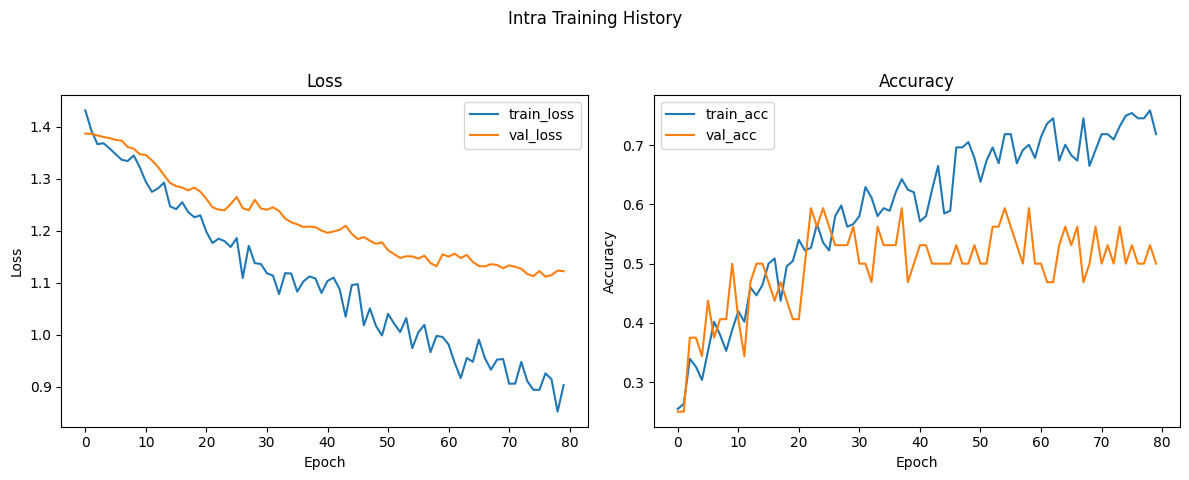

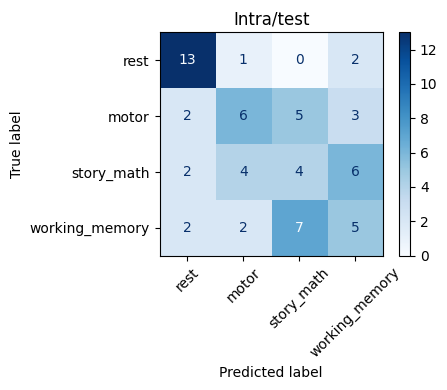


============ Intra/test ============:
                     precision    recall  f1-score   support

               rest      0.684     0.812     0.743        16
         task_motor      0.462     0.375     0.414        16
    task_story_math      0.250     0.250     0.250        16
task_working_memory      0.312     0.312     0.312        16

           accuracy                          0.438        64
          macro avg      0.427     0.438     0.430        64
       weighted avg      0.427     0.438     0.430        64



In [30]:
visualize_results(intra_history, intra_predictions, title_prefix='Intra', save_dir=Path('./results'))

### Cross

In [31]:

def cross_split(files, validation_fraction=0.2, seed=42):
    """Split the filepaths based on (subject, label), keeping both subjects and all classes in both train and validation sets"""
    rng = np.random.default_rng(seed)
    files = list(files)

    # group files by subject and task label
    group = {}
    
    for f in files:
        key = (get_subject(f), get_label(f)) 
        group.setdefault(key, []).append(f)

    
    # split subjects into train and validation
    train_files, val_files = [], []
    for key, group_files in group.items():
        shuffled_group = list(rng.permutation(group_files))
        n_val = max(1, int(len(shuffled_group) * validation_fraction)) # at least 1 sample for validation
        val_files.extend(shuffled_group[:n_val])
        train_files.extend(shuffled_group[n_val:])
    
     # shuffle the final train and validation lists
    train_files = rng.permutation(train_files).tolist()
    val_files = rng.permutation(val_files).tolist()

    
    return train_files, val_files



def run_cross(epochs=80, seed=42, use_subject_norm=True):
    all_train_files = list_files(CROSS_TRAIN)
    train_files, validation_files = cross_split(all_train_files, seed=seed)
    test_files = {
        'Cross/test1': list_files(CROSS_TEST1),
        'Cross/test2': list_files(CROSS_TEST2),
        'Cross/test3': list_files(CROSS_TEST3),
    }


    return run_eegnet(train_files, validation_files, test_files, batch_size=16, epochs=epochs, use_subject_norm=use_subject_norm)

In [32]:
# without subject-based normalization
cross_model_no_norm, cross_history_no_norm, cross_results_no_norm , cross_predictions_no_norm = run_cross(use_subject_norm=False)


Building training dataset
Loaded 448 windows from 56 files. Class distribution: [112 112 112 112]
Building validation dataset
Loaded 64 windows from 8 files. Class distribution: [16 16 16 16]
Building test dataset
Loaded 128 windows from 16 files. Class distribution: [32 32 32 32]
Loaded 128 windows from 16 files. Class distribution: [32 32 32 32]
Loaded 128 windows from 16 files. Class distribution: [32 32 32 32]
Epoch 1/80
28/28 - 14s - 487ms/step - accuracy: 0.2455 - loss: 1.4120 - val_accuracy: 0.1719 - val_loss: 1.3933 - learning_rate: 5.0000e-04
Epoch 2/80
28/28 - 13s - 448ms/step - accuracy: 0.2634 - loss: 1.3799 - val_accuracy: 0.2656 - val_loss: 1.3858 - learning_rate: 5.0000e-04
Epoch 3/80
28/28 - 12s - 431ms/step - accuracy: 0.2924 - loss: 1.3798 - val_accuracy: 0.2969 - val_loss: 1.3837 - learning_rate: 5.0000e-04
Epoch 4/80
28/28 - 12s - 444ms/step - accuracy: 0.3013 - loss: 1.3718 - val_accuracy: 0.2188 - val_loss: 1.3846 - learning_rate: 5.0000e-04
Epoch 5/80
28/28 - 13s

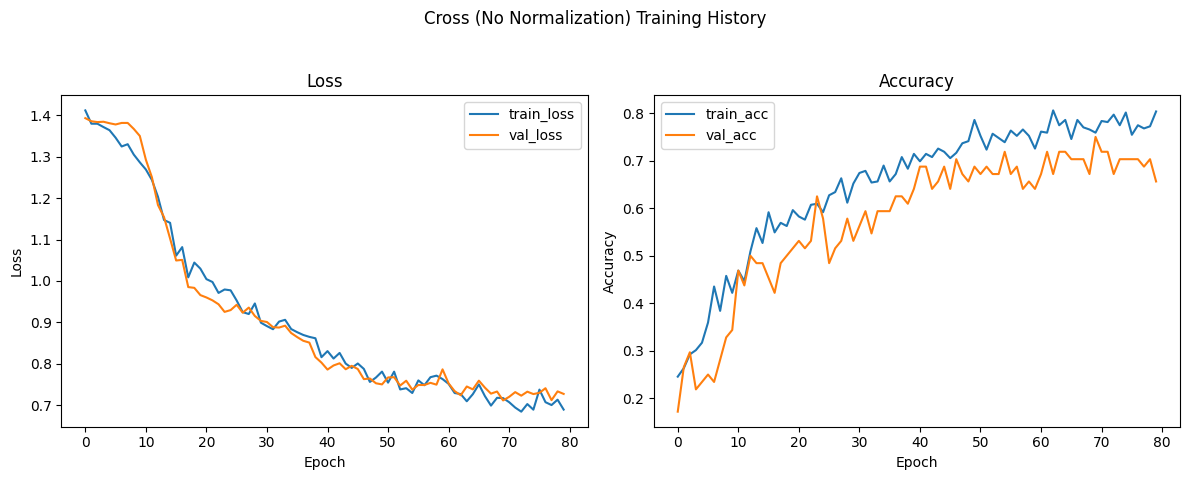

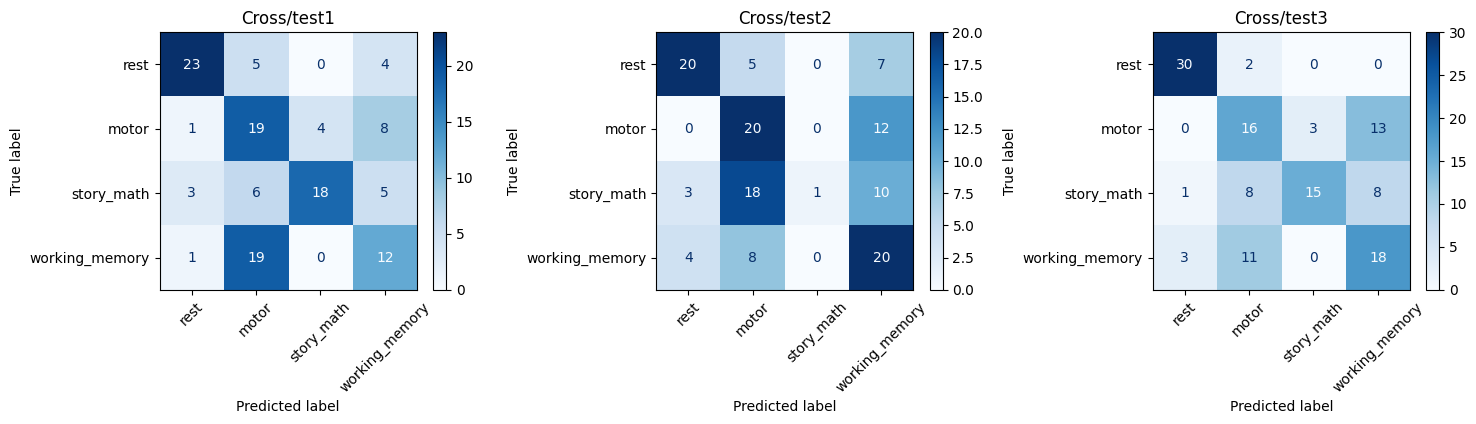


============ Cross/test1 ============:
                     precision    recall  f1-score   support

               rest      0.821     0.719     0.767        32
         task_motor      0.388     0.594     0.469        32
    task_story_math      0.818     0.562     0.667        32
task_working_memory      0.414     0.375     0.393        32

           accuracy                          0.562       128
          macro avg      0.610     0.562     0.574       128
       weighted avg      0.610     0.562     0.574       128


============ Cross/test2 ============:
                     precision    recall  f1-score   support

               rest      0.741     0.625     0.678        32
         task_motor      0.392     0.625     0.482        32
    task_story_math      1.000     0.031     0.061        32
task_working_memory      0.408     0.625     0.494        32

           accuracy                          0.477       128
          macro avg      0.635     0.477     0.429       128


In [33]:
visualize_results(cross_history_no_norm, cross_predictions_no_norm, title_prefix='Cross (No Normalization)', save_dir=Path('./results'))

In [34]:
# with subject-based normalization

cross_model, cross_history, cross_results , cross_predictions = run_cross(use_subject_norm=True)


Computing per-subject statistics for normalization...
Building training dataset
Loaded 448 windows from 56 files. Class distribution: [112 112 112 112]
Building validation dataset
Loaded 64 windows from 8 files. Class distribution: [16 16 16 16]
Building test dataset
Loaded 128 windows from 16 files. Class distribution: [32 32 32 32]
Loaded 128 windows from 16 files. Class distribution: [32 32 32 32]
Loaded 128 windows from 16 files. Class distribution: [32 32 32 32]
Epoch 1/80
28/28 - 6s - 212ms/step - accuracy: 0.5759 - loss: 1.1084 - val_accuracy: 1.0000 - val_loss: 0.8416 - learning_rate: 5.0000e-04
Epoch 2/80
28/28 - 6s - 222ms/step - accuracy: 0.8281 - loss: 0.7035 - val_accuracy: 1.0000 - val_loss: 0.4380 - learning_rate: 5.0000e-04
Epoch 3/80
28/28 - 7s - 256ms/step - accuracy: 0.8594 - loss: 0.5590 - val_accuracy: 1.0000 - val_loss: 0.3023 - learning_rate: 5.0000e-04
Epoch 4/80
28/28 - 8s - 271ms/step - accuracy: 0.8817 - loss: 0.4592 - val_accuracy: 1.0000 - val_loss: 0.2167 

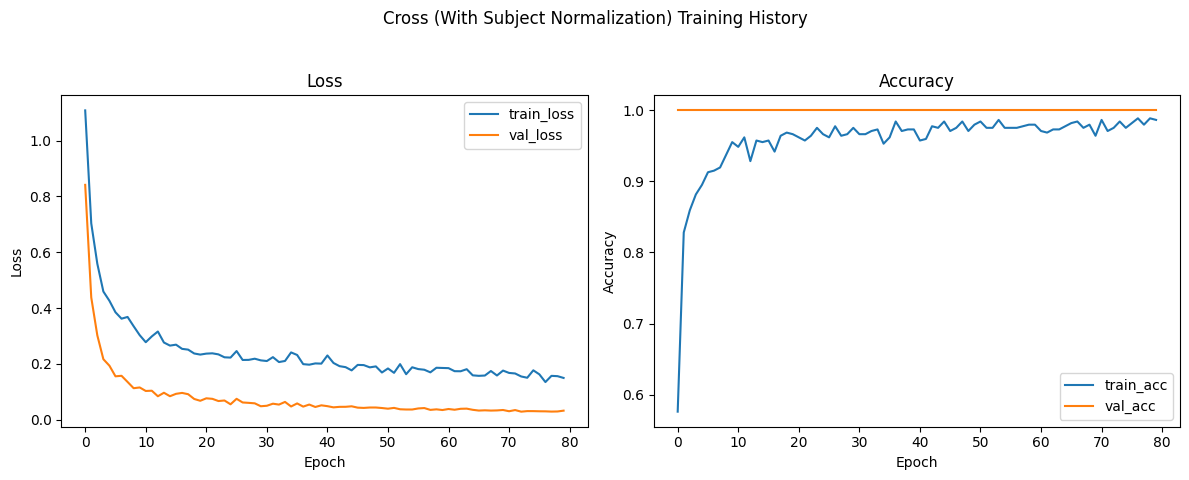

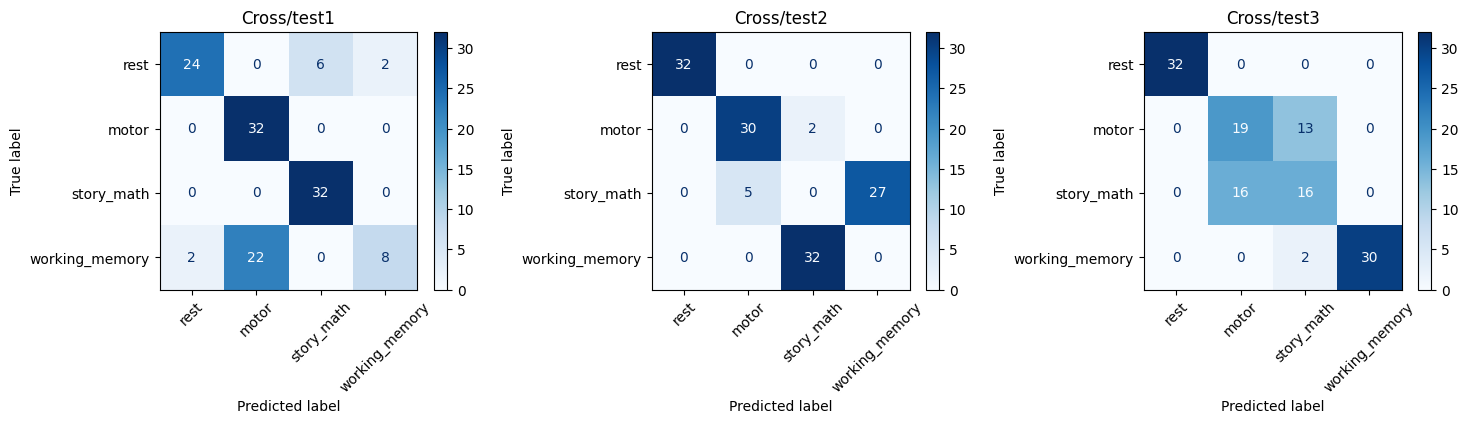


============ Cross/test1 ============:
                     precision    recall  f1-score   support

               rest      0.923     0.750     0.828        32
         task_motor      0.593     1.000     0.744        32
    task_story_math      0.842     1.000     0.914        32
task_working_memory      0.800     0.250     0.381        32

           accuracy                          0.750       128
          macro avg      0.789     0.750     0.717       128
       weighted avg      0.789     0.750     0.717       128


============ Cross/test2 ============:
                     precision    recall  f1-score   support

               rest      1.000     1.000     1.000        32
         task_motor      0.857     0.938     0.896        32
    task_story_math      0.000     0.000     0.000        32
task_working_memory      0.000     0.000     0.000        32

           accuracy                          0.484       128
          macro avg      0.464     0.484     0.474       128


In [35]:
visualize_results(cross_history, cross_predictions, title_prefix='Cross (With Subject Normalization)', save_dir=Path('./results'))

In [13]:
seeds = [42, 7, 123, 2024, 0]
intra_test_accs = []
for s in seeds:
    print(f"\n=== seed={s} ===")
    _, _, results, _ = run_intra(seed=s, epochs=80)
    intra_test_accs.append(results['Intra/test'][1])

print(f"\nMean ± std over seeds: {np.mean(intra_test_accs):.3f} ± {np.std(intra_test_accs):.3f}")
print(f"All: {intra_test_accs}")


=== seed=42 ===
Building training dataset
Loaded 224 windows from 28 files. Class distribution: [56 56 56 56]
Building validation dataset
Loaded 32 windows from 4 files. Class distribution: [8 8 8 8]
Building test dataset
Loaded 64 windows from 8 files. Class distribution: [16 16 16 16]
Epoch 1/80
14/14 - 3s - 212ms/step - accuracy: 0.2679 - loss: 1.4264 - val_accuracy: 0.3125 - val_loss: 1.3817 - learning_rate: 5.0000e-04
Epoch 2/80
14/14 - 2s - 117ms/step - accuracy: 0.3080 - loss: 1.3896 - val_accuracy: 0.2188 - val_loss: 1.3813 - learning_rate: 5.0000e-04
Epoch 3/80
14/14 - 2s - 122ms/step - accuracy: 0.3170 - loss: 1.3657 - val_accuracy: 0.2500 - val_loss: 1.3776 - learning_rate: 5.0000e-04
Epoch 4/80
14/14 - 2s - 125ms/step - accuracy: 0.3438 - loss: 1.3646 - val_accuracy: 0.3438 - val_loss: 1.3772 - learning_rate: 5.0000e-04
Epoch 5/80
14/14 - 2s - 129ms/step - accuracy: 0.3125 - loss: 1.3625 - val_accuracy: 0.3125 - val_loss: 1.3711 - learning_rate: 5.0000e-04
Epoch 6/80
14/14